In [1]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import pandas as pd

# Load a small pre-trained model
model_name = "distilgpt2"  # Small model for demo
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Add padding token if it doesn't exist
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [2]:
# Sample customer service dataset
training_data = [
    {
        "instruction": "How do I reset my password?",
        "response": "To reset your password, click on 'Forgot Password' on the login page. You'll receive an email with reset instructions within 5 minutes."
    },
    {
        "instruction": "My order hasn't arrived yet",
        "response": "I apologize for the delay. Could you please provide your order number? I'll track it immediately and give you an update."
    },
    {
        "instruction": "What's your return policy?",
        "response": "We offer 30-day returns for all unused items. Please keep the original packaging and include the receipt for a full refund."
    },
    {
        "instruction": "The app keeps crashing",
        "response": "I'm sorry you're experiencing issues. Let's try clearing the app cache or reinstalling. If the problem persists, please share your device model and OS version."
    }
]

# Format the data for training
def format_instruction(example):
    return f"### Instruction:\n{example['instruction']}\n\n### Response:\n{example['response']}"

formatted_data = [{"text": format_instruction(item)} for item in training_data]
dataset = Dataset.from_list(formatted_data)


In [3]:
# 1. LARGER, MORE DIVERSE DATASET (20+ examples)
training_data = [
    # Password/Account issues
    {"instruction": "How do I reset my password?",
     "response": "To reset your password, click 'Forgot Password' on the login page. You'll receive a reset link via email within 5 minutes."},
    {"instruction": "I forgot my username",
     "response": "Your username is the email address you used to register. If you're still having trouble, contact support with your phone number."},
    {"instruction": "Can I change my email address?",
     "response": "Yes, go to Account Settings > Profile > Email. You'll need to verify the new email address before the change takes effect."},

    # Order issues
    {"instruction": "My order hasn't arrived yet",
     "response": "I apologize for the delay. Please provide your order number and I'll track it immediately. Delivery typically takes 3-5 business days."},
    {"instruction": "Where is my package?",
     "response": "You can track your package using the tracking link in your shipping confirmation email. If you need assistance, share your order number."},
    {"instruction": "Can I cancel my order?",
     "response": "Orders can be cancelled within 1 hour of placement. Please check your order status in your account or contact support immediately."},

    # Returns/Refunds
    {"instruction": "What's your return policy?",
     "response": "We offer 30-day returns for unused items in original packaging. Print a return label from your account or contact support."},
    {"instruction": "How long do refunds take?",
     "response": "Refunds process within 5-7 business days after we receive your return. The time for funds to appear depends on your bank."},
    {"instruction": "I received a damaged item",
     "response": "I'm sorry to hear that. Please send photos of the damage to support@company.com with your order number, and we'll replace it immediately."},

    # Technical issues
    {"instruction": "The app keeps crashing",
     "response": "Let's troubleshoot: 1) Update to latest version 2) Clear app cache 3) Reinstall. If issues persist, share your device model and OS."},
    {"instruction": "Website is slow",
     "response": "Try clearing your browser cache or using incognito mode. If the issue continues, please let us know your browser version and location."},
    {"instruction": "Payment not working",
     "response": "Ensure your card details are correct and you have sufficient funds. Try a different payment method or contact your bank."},

    # Product questions
    {"instruction": "Do you have this in blue?",
     "response": "The blue variant is currently in stock! Check product page for size availability. We also have navy and sky blue options."},
    {"instruction": "What's the size chart?",
     "response": "Our size chart is available on each product page. For custom sizing, please provide your measurements and we'll recommend the best fit."},
    {"instruction": "Is this waterproof?",
     "response": "This item has water-resistant coating but isn't fully waterproof. It can handle light rain but shouldn't be submerged."},

    # Shipping
    {"instruction": "Do you ship internationally?",
     "response": "Yes, we ship to over 50 countries. Shipping costs and delivery times vary by location. Check our shipping policy for details."},
    {"instruction": "How much is shipping?",
     "response": "Standard shipping is free on orders over $50. Otherwise, it's $5.99. Express shipping options are available at checkout."},
    {"instruction": "Express shipping options",
     "response": "We offer 2-day express ($12.99) and next-day ($24.99) shipping. Orders must be placed by 2 PM for next-day delivery."},

    # Account management
    {"instruction": "Delete my account",
     "response": "To delete your account, go to Settings > Privacy > Delete Account. This action is permanent and cannot be undone."},
    {"instruction": "Update payment method",
     "response": "You can update payment methods in Account > Payment Methods. Add a new card or remove old ones for future purchases."},
    {"instruction": "Subscription not working",
     "response": "Check your subscription status in Account > Subscriptions. If payments are failing, update your payment method or contact support."},
]


In [4]:
dataset[3]

{'text': "### Instruction:\nThe app keeps crashing\n\n### Response:\nI'm sorry you're experiencing issues. Let's try clearing the app cache or reinstalling. If the problem persists, please share your device model and OS version."}

In [5]:
def tokenize_function(examples):
    # Tokenize with labels (same as input_ids for language modeling)
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

# Tokenize the dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

In [6]:
tokenized_dataset[0]

{'input_ids': [21017,
  46486,
  25,
  198,
  2437,
  466,
  314,
  13259,
  616,
  9206,
  30,
  198,
  198,
  21017,
  18261,
  25,
  198,
  2514,
  13259,
  534,
  9206,
  11,
  3904,
  319,
  705,
  1890,
  23442,
  30275,
  6,
  319,
  262,
  17594,
  2443,
  13,
  921,
  1183,
  3328,
  281,
  3053,
  351,
  13259,
  7729,
  1626,
  642,
  2431,
  13,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
  50256,
 

In [7]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./customer-service-model",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_steps=10,
    logging_steps=10,
    learning_rate=5e-5,
    save_total_limit=2,
)

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
)

# Fine-tune the model
trainer.train()

# Save the fine-tuned model
model.save_pretrained("./customer-service-model-final")
tokenizer.save_pretrained("./customer-service-model-final")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./customer-service-model-final/tokenizer_config.json',
 './customer-service-model-final/tokenizer.json')

In [8]:
def generate_response(model, tokenizer, instruction):
    prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=50)

    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_length=100,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response


In [9]:
# Test before fine-tuning (using original model)
original_model = AutoModelForCausalLM.from_pretrained("distilgpt2")

# Test after fine-tuning
fine_tuned_model = AutoModelForCausalLM.from_pretrained("./customer-service-model-final")

# Test questions
test_questions = [
    "How do I reset my password?",
    "What's your return policy?"
]

print("BEFORE FINE-TUNING:")
print("-" * 50)
for question in test_questions:
    response = generate_response(original_model, tokenizer, question)
    print(f"Q: {question}")
    print(f"A: {response}")
    print()

print("\nAFTER FINE-TUNING:")
print("-" * 50)
for question in test_questions:
    response = generate_response(fine_tuned_model, tokenizer, question)
    print(f"Q: {question}")
    print(f"A: {response}")
    print()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BEFORE FINE-TUNING:
--------------------------------------------------
Q: How do I reset my password?
A: ### Instruction:
How do I reset my password?

### Response:
I reset my password.
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###
###

Q: What's your return policy?
A: ### Instruction:
What's your return policy?

### Response:
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for the inconvenience.
###
We're sorry for


AFTER FINE-TUNING:
--------------------------------------------------
Q: How do I reset my password?
A: ### Instruction:
How do I reset my password?

### Response:

Please enable JavaScript to view the comments powered by Disqus.

Q: W

What is the problem here?


### How to imporve?

1. Dataset Size Too Small

4 examples is far too little for meaningful fine-tuning. The model essentially memorizes these few examples without learning general patterns.

2. Missing Loss Masking

The demo calculates loss on all tokens, including the instruction part. This teaches the model to predict instructions, not just generate good responses.

3. No Evaluation/Validation

Without validation, we can't tell if the model is actually learning or just overfitting.


In [10]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from datasets import Dataset
import numpy as np

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model and move to device
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Move model to appropriate device
model = model.to(device)
print(f"Model moved to: {next(model.parameters()).device}")

# Fix tokenizer
tokenizer.pad_token = tokenizer.eos_token

# 1. LARGER, MORE DIVERSE DATASET (20+ examples)
training_data = [
    # Password/Account issues
    {"instruction": "How do I reset my password?",
     "response": "To reset your password, click 'Forgot Password' on the login page. You'll receive a reset link via email within 5 minutes."},
    {"instruction": "I forgot my username",
     "response": "Your username is the email address you used to register. If you're still having trouble, contact support with your phone number."},
    {"instruction": "Can I change my email address?",
     "response": "Yes, go to Account Settings > Profile > Email. You'll need to verify the new email address before the change takes effect."},

    # Order issues
    {"instruction": "My order hasn't arrived yet",
     "response": "I apologize for the delay. Please provide your order number and I'll track it immediately. Delivery typically takes 3-5 business days."},
    {"instruction": "Where is my package?",
     "response": "You can track your package using the tracking link in your shipping confirmation email. If you need assistance, share your order number."},
    {"instruction": "Can I cancel my order?",
     "response": "Orders can be cancelled within 1 hour of placement. Please check your order status in your account or contact support immediately."},

    # Returns/Refunds
    {"instruction": "What's your return policy?",
     "response": "We offer 30-day returns for unused items in original packaging. Print a return label from your account or contact support."},
    {"instruction": "How long do refunds take?",
     "response": "Refunds process within 5-7 business days after we receive your return. The time for funds to appear depends on your bank."},
    {"instruction": "I received a damaged item",
     "response": "I'm sorry to hear that. Please send photos of the damage to support@company.com with your order number, and we'll replace it immediately."},

    # Technical issues
    {"instruction": "The app keeps crashing",
     "response": "Let's troubleshoot: 1) Update to latest version 2) Clear app cache 3) Reinstall. If issues persist, share your device model and OS."},
    {"instruction": "Website is slow",
     "response": "Try clearing your browser cache or using incognito mode. If the issue continues, please let us know your browser version and location."},
    {"instruction": "Payment not working",
     "response": "Ensure your card details are correct and you have sufficient funds. Try a different payment method or contact your bank."},

    # Product questions
    {"instruction": "Do you have this in blue?",
     "response": "The blue variant is currently in stock! Check product page for size availability. We also have navy and sky blue options."},
    {"instruction": "What's the size chart?",
     "response": "Our size chart is available on each product page. For custom sizing, please provide your measurements and we'll recommend the best fit."},
    {"instruction": "Is this waterproof?",
     "response": "This item has water-resistant coating but isn't fully waterproof. It can handle light rain but shouldn't be submerged."},

    # Shipping
    {"instruction": "Do you ship internationally?",
     "response": "Yes, we ship to over 50 countries. Shipping costs and delivery times vary by location. Check our shipping policy for details."},
    {"instruction": "How much is shipping?",
     "response": "Standard shipping is free on orders over $50. Otherwise, it's $5.99. Express shipping options are available at checkout."},
    {"instruction": "Express shipping options",
     "response": "We offer 2-day express ($12.99) and next-day ($24.99) shipping. Orders must be placed by 2 PM for next-day delivery."},

    # Account management
    {"instruction": "Delete my account",
     "response": "To delete your account, go to Settings > Privacy > Delete Account. This action is permanent and cannot be undone."},
    {"instruction": "Update payment method",
     "response": "You can update payment methods in Account > Payment Methods. Add a new card or remove old ones for future purchases."},
    {"instruction": "Subscription not working",
     "response": "Check your subscription status in Account > Subscriptions. If payments are failing, update your payment method or contact support."},
]


# Format data
def format_data(example):
    prompt = f"Instruction: {example['instruction']}\nResponse: "
    completion = f"{example['response']}"
    full_text = prompt + completion

    return {
        "text": full_text,
        "prompt_length": len(tokenizer.encode(prompt))
    }

formatted_data = [format_data(item) for item in training_data]
dataset = Dataset.from_list(formatted_data)

# Tokenize
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

    tokenized["labels"] = tokenized["input_ids"].clone()

    for i, prompt_len in enumerate(examples["prompt_length"]):
        tokenized["labels"][i, :prompt_len] = -100

    return tokenized

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "prompt_length"]
)

# Training arguments
training_args = TrainingArguments(
    output_dir="./customer-service-model",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    logging_dir='./logs',
    logging_steps=10,
    save_steps=50,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=100,
    # Important: Don't set no_cuda, let it auto-detect
)

# Data collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

# Train
print("Starting training...")
trainer.train()
print("Training completed!")

# Save model
model.save_pretrained("./customer-service-model-final")
tokenizer.save_pretrained("./customer-service-model-final")

# FIXED: Test function with proper device handling
def test_model(model, tokenizer, instruction, device):
    """Test model with proper device placement"""
    prompt = f"Instruction: {instruction}\nResponse: "

    # Tokenize and move inputs to the same device as model
    inputs = tokenizer(prompt, return_tensors="pt")

    # Move all input tensors to the model's device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Generate
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            attention_mask=inputs.get("attention_mask", None),
            max_length=100,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode and extract response
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Response: " in response:
        response = response.split("Response: ")[-1]

    return response

# Test the fine-tuned model
print("\n" + "="*50)
print("TESTING THE FINE-TUNED MODEL")
print("="*50)

test_questions = [
    "How do I reset my password?",
    "My order hasn't arrived yet",
    "The app keeps crashing",
]

for question in test_questions:
    response = test_model(model, tokenizer, question, device)
    print(f"\nQ: {question}")
    print(f"A: {response}")
    print("-"*30)

# Compare with original model (on same device)
print("\n" + "="*50)
print("COMPARING WITH ORIGINAL MODEL")
print("="*50)

original_model = AutoModelForCausalLM.from_pretrained("distilgpt2")
original_model = original_model.to(device)

for question in test_questions:
    response = test_model(original_model, tokenizer, question, device)
    print(f"\nQ: {question}")
    print(f"A: {response}")
    print("-"*30)

Using device: cpu


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model moved to: cpu


Map:   0%|          | 0/21 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Training completed!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TESTING THE FINE-TUNED MODEL


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/generation/utils.py:2503: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on mps. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('mps') before running `.generate()`.
  warnings.warn(


RuntimeError: Placeholder storage has not been allocated on MPS device!

###Does SFT Train the Whole Model Parameters?

In standard SFT, all parameters of the model are updated during training. This means every weight in every layer gets adjusted based on the new supervised data.

This trains ALL parameters

model = AutoModelForCausalLM.from_pretrained("llama-2-7b")

trainer = Trainer(model=model, ...)  # All 7B parameters will be updated!

###How can we improve it?

Parameter-Efficient Fine-Tuning (PEFT)

LoRA (Low-Rank Adaptation)



1.   Only trains small adapter matrices inserted into the model
2.   Typically <1% of total parameters are trainable
3.   Original model weights are frozen











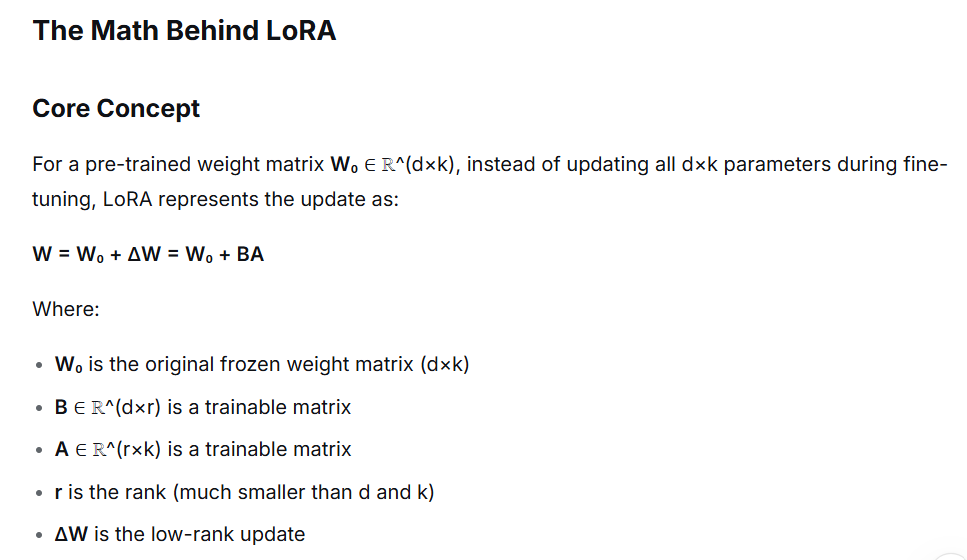

Why This Works
The parameter count changes from:

Full fine-tuning: d × k parameters to update

LoRA: d × r + r × k = r(d + k) parameters to update

With r << min(d,k), this is dramatically smaller!

In [ ]:
#LoRA Parameters Explained

from peft import LoraConfig

lora_config = LoraConfig(
    r=8,                          # Rank
    lora_alpha=32,                 # Scaling factor
    target_modules=["q_proj", "v_proj"],  # Which modules to adapt
    lora_dropout=0.1,              # Dropout probability
    bias="none",                   # Bias handling
    task_type="CAUSAL_LM"          # Task type
)

In [ ]:
#r (Rank) - The Most Important Parameter
#Math: Controls the rank of matrices A and B

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def demonstrate_rank_impact(original_weight, r_values):
    """
    Show how rank affects the update matrix
    """
    d, k = original_weight.shape

    print(f"Original weight shape: {original_weight.shape}")
    print(f"Total parameters in original: {d * k}")
    print()

    results = []
    for r in r_values:
        # Initialize LoRA matrices
        A = nn.Parameter(torch.randn(r, k) * 0.01)
        B = nn.Parameter(torch.randn(d, r) * 0.01)

        # Calculate update
        delta_W = B @ A

        # Count trainable parameters
        trainable_params = d * r + r * k
        compression_ratio = (d * k) / trainable_params

        results.append({
            'r': r,
            'trainable_params': trainable_params,
            'compression_ratio': compression_ratio,
            'delta_W_norm': torch.norm(delta_W).item()
        })

        print(f"r = {r}:")
        print(f"  Trainable parameters: {trainable_params}")
        print(f"  Compression ratio: {compression_ratio:.2f}x")
        print(f"  Update matrix shape: {delta_W.shape}")
        print(f"  Update norm: {torch.norm(delta_W).item():.4f}")
        print()

    return results

# Demonstrate with a typical attention layer dimension
d, k = 768, 768  # Typical for BERT-base
original_weight = torch.randn(d, k)
r_values = [1, 2, 4, 8, 16, 32, 64]

print("IMPACT OF RANK (r) ON LORA")
print("=" * 50)
results = demonstrate_rank_impact(original_weight, r_values)

# Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot([r['r'] for r in results], [r['compression_ratio'] for r in results], 'bo-')
plt.xlabel('Rank (r)')
plt.ylabel('Compression Ratio')
plt.title('Compression Ratio vs Rank')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot([r['r'] for r in results], [r['delta_W_norm'] for r in results], 'ro-')
plt.xlabel('Rank (r)')
plt.ylabel('Update Norm')
plt.title('Update Magnitude vs Rank')

plt.tight_layout()
plt.show()


In [ ]:
#lora_alpha (Scaling Factor)
#Math: The actual update is: ΔW = (lora_alpha / r) × BA

def demonstrate_alpha_scaling():
    """
    Show how alpha affects the update magnitude
    """
    d, k, r = 768, 768, 8

    # Fixed LoRA matrices
    A = torch.randn(r, k) * 0.01
    B = torch.randn(d, r) * 0.01
    base_update = B @ A

    alpha_values = [1, 2, 4, 8, 16, 32, 64]

    print("IMPACT OF LORA_ALPHA ON UPDATE SCALING")
    print("=" * 50)
    print(f"Base update norm: {torch.norm(base_update):.4f}")
    print()

    for alpha in alpha_values:
        scaling = alpha / r
        scaled_update = base_update * scaling
        print(f"alpha = {alpha:2d}, scaling = {scaling:.2f}x, update norm = {torch.norm(scaled_update):.4f}")

    # Mathematical relationship
    print("\n" + "=" * 50)
    print("MATHEMATICAL RELATIONSHIP:")
    print("ΔW = (α/r) × BA")
    print("Where:")
    print("  α = lora_alpha")
    print("  r = rank")
    print("  BA = learned low-rank product")

demonstrate_alpha_scaling()


In [ ]:
#target_modules - Which Layers to Adapt

def demonstrate_target_modules():
    """
    Show how targeting different modules affects parameter count
    """
    class TransformerLayer:
        def __init__(self, hidden_size=768, num_heads=12):
            self.hidden_size = hidden_size
            self.num_heads = num_heads
            self.head_dim = hidden_size // num_heads

            # Attention projections
            self.q_proj = nn.Linear(hidden_size, hidden_size)
            self.k_proj = nn.Linear(hidden_size, hidden_size)
            self.v_proj = nn.Linear(hidden_size, hidden_size)
            self.o_proj = nn.Linear(hidden_size, hidden_size)

            # FFN layers
            self.fc1 = nn.Linear(hidden_size, hidden_size * 4)
            self.fc2 = nn.Linear(hidden_size * 4, hidden_size)

    def calculate_lora_params(modules_to_adapt, hidden_size=768, r=8):
        """Calculate trainable parameters for given modules"""
        total_params = 0
        module_params = {}

        for module in modules_to_adapt:
            # For each module: LoRA adds d×r + r×k parameters
            # In self-attention, d = k = hidden_size
            params = 2 * hidden_size * r  # B (d×r) + A (r×k)
            module_params[module] = params
            total_params += params

        return total_params, module_params

    hidden_size = 768
    r = 8

    module_combinations = [
        (["q_proj"], "Query only"),
        (["v_proj"], "Value only"),
        (["q_proj", "v_proj"], "Q and V (most common)"),
        (["q_proj", "k_proj", "v_proj"], "Q, K, V"),
        (["q_proj", "v_proj", "o_proj"], "All attention"),
        (["q_proj", "v_proj", "fc1", "fc2"], "Attention + FFN"),
    ]

    print("IMPACT OF TARGET_MODULES ON PARAMETER COUNT")
    print("=" * 60)
    print(f"Hidden size: {hidden_size}, Rank (r): {r}")
    print()

    for modules, description in module_combinations:
        total_params, module_params = calculate_lora_params(modules, hidden_size, r)

        print(f"\n{description}:")
        print(f"  Modules: {modules}")
        for module, params in module_params.items():
            print(f"    {module}: {params:,} parameters")
        print(f"  TOTAL: {total_params:,} trainable parameters")

    # Full fine-tuning comparison
    full_ft_params = hidden_size * hidden_size * 4  # Q,K,V,O only
    print(f"\n" + "=" * 60)
    print(f"Full fine-tuning (all attention): {full_ft_params:,} parameters")
    print(f"LoRA compression: {full_ft_params / total_params:.1f}x smaller")

demonstrate_target_modules()


In [ ]:
# lora_dropout - Regularization
def demonstrate_dropout_effect():
    """
    Show how dropout affects training
    """
    import torch.nn.functional as F

    # Create sample LoRA output
    batch_size, seq_len, hidden_size = 32, 128, 768
    r = 8

    # Simulate LoRA output before scaling
    lora_output = torch.randn(batch_size, seq_len, hidden_size)

    dropout_probs = [0.0, 0.05, 0.1, 0.2, 0.3]

    print("IMPACT OF LORA_DROPOUT")
    print("=" * 50)
    print(f"Input statistics - Mean: {lora_output.mean():.4f}, Std: {lora_output.std():.4f}")
    print()

    for dropout_prob in dropout_probs:
        # Apply dropout in training mode
        training_output = F.dropout(lora_output, p=dropout_prob, training=True)
        eval_output = F.dropout(lora_output, p=dropout_prob, training=False)

        # Calculate statistics
        training_zeros = (training_output == 0).float().mean()
        training_mean = training_output.mean()

        print(f"Dropout = {dropout_prob:.0%}:")
        print(f"  Training: {training_zeros:.1%} zeros, mean = {training_mean:.4f}")
        print(f"  Evaluation: mean = {eval_output.mean():.4f} (no dropout)")
        print()

    print("\nMATHEMATICAL EFFECT:")
    print("During training: output = (1/(1-p)) × mask × input")
    print("During inference: output = input (no dropout)")
    print("This prevents co-adaptation in LoRA matrices")

demonstrate_dropout_effect()

In [ ]:
#bias - Handling Bias Parameters
def demonstrate_bias_options():
    """
    Show different bias handling strategies
    """
    bias_options = {
        "none": "No bias training",
        "all": "Train all biases",
        "lora_only": "Train only biases in adapted modules"
    }

    hidden_size = 768
    num_layers = 12
    r = 8

    print("BIAS HANDLING OPTIONS")
    print("=" * 50)

    # Calculate parameters for each option
    lora_params = 4 * 2 * hidden_size * r  # Q,K,V,O for 4 modules
    bias_params_per_layer = 4 * hidden_size  # Q,K,V,O biases
    total_bias_params = bias_params_per_layer * num_layers

    for option, description in bias_options.items():
        if option == "none":
            params = lora_params
        elif option == "all":
            params = lora_params + total_bias_params
        else:  # lora_only
            params = lora_params + bias_params_per_layer * num_layers  # Same as "all" for simplicity

        print(f"\n{option}:")
        print(f"  {description}")
        print(f"  Trainable parameters: {params:,}")

        if option == "none":
            print("  Mathematical: W = W₀ + BA (frozen biases)")
        elif option == "all":
            print("  Mathematical: W = W₀ + BA, b = b₀ + Δb")
        else:
            print("  Mathematical: W = W₀ + BA for adapted modules, b = b₀ + Δb for same modules")

demonstrate_bias_options()

In [ ]:
#Complete Mathematical Derivation

def lora_mathematical_demo():
    """
    Complete mathematical demonstration of LoRA
    """
    import sympy as sp

    print("COMPLETE LORA MATHEMATICAL FRAMEWORK")
    print("=" * 60)

    # Define symbols
    d, k, r = sp.symbols('d k r', positive=True, integer=True)
    alpha = sp.symbols('alpha', positive=True)

    # Original weight
    W0 = sp.MatrixSymbol('W₀', d, k)

    # LoRA matrices
    B = sp.MatrixSymbol('B', d, r)
    A = sp.MatrixSymbol('A', r, k)

    # Forward pass
    print("\n1. FORWARD PASS:")
    print("   h = W₀x + ΔWx")
    print("   ΔW = (α/r) × BA")
    print("\n   Expanded:")
    print(f"   h = W₀x + (α/r) × B × A × x")

    # Parameter count
    print("\n2. PARAMETER COUNT:")
    original_params = d * k
    lora_params = d * r + r * k
    print(f"   Original: {original_params} parameters")
    print(f"   LoRA: {lora_params} parameters")
    print(f"   Reduction: ({original_params})"+"/"+f" ({lora_params}) x")

    # Gradient flow
    print("\n3. GRADIENT FLOW:")
    print("   ∂L/∂B = (α/r) × (∂L/∂h) × (Ax)ᵀ")
    print("   ∂L/∂A = (α/r) × Bᵀ × (∂L/∂h) × xᵀ")
    print("   ∂L/∂W₀ = 0 (frozen)")

    # Initialization
    print("\n4. INITIALIZATION:")
    print("   A ∼ N(0, σ²)  (usually σ=0.01)")
    print("   B = 0")
    print("   Therefore ΔW = 0 at start of training")

    # Merging
    print("\n5. MERGING FOR INFERENCE:")
    print("   W_merged = W₀ + (α/r) × BA")
    print("   No inference overhead!")

lora_mathematical_demo()

In [ ]:
from peft import LoraConfig, get_peft_model

# Configure LoRA
lora_config = LoraConfig(
    r=8,  # rank
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # Which layers to adapt
    lora_dropout=0.1,
)

# Freeze original model, add trainable adapters
model = AutoModelForCausalLM.from_pretrained("llama-2-7b")
peft_model = get_peft_model(model, lora_config)

# Check trainable parameters
peft_model.print_trainable_parameters()
# Output: trainable params: 4,194,304 || all params: 6,742,473,216 || trainable%: 0.0622

Full Fine-Tuning vs PEFT Comparison

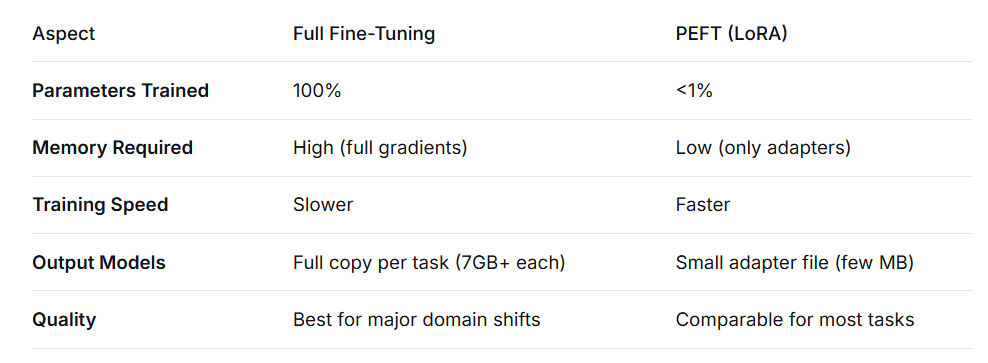

When to Train All Parameters vs PEFT

In [ ]:
#Train ALL Parameters When:
# 1. Major domain shift (e.g., general → medical)
# 2. You have lots of high-quality data (100k+ examples)
# 3. You need maximum performance
# 4. You have computational resources

In [ ]:
#Use PEFT (LoRA) When:
# 1. Limited data (hundreds/thousands of examples)
# 2. Quick experimentation
# 3. Multiple task adaptations
# 4. Memory-constrained environments
# 5. Preventing catastrophic forgetting

In [ ]:
#LoRA SFT
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

# 1. Load base model (frozen by default)
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",  # Small model for demo
    torch_dtype=torch.float16,
    device_map="auto"
)

# 2. Configure LoRA - only ~0.1% of parameters will be trainable
lora_config = LoraConfig(
    r=16,  # Rank - higher = more parameters
    lora_alpha=32,  # Scaling factor
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # Attention layers
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# 3. Apply LoRA - original weights frozen, adapters added
peft_model = get_peft_model(model, lora_config)

# Check what's trainable
print("Trainable parameters:")
for name, param in peft_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}")

# Output shows only LoRA adapter weights:
#   base_model.model.transformer.h.0.attn.q_proj.lora_A.weight
#   base_model.model.transformer.h.0.attn.q_proj.lora_B.weight
#   ... (only adapter matrices, not original weights)

# 4. Prepare training data (same as before)
training_data = [
    {"instruction": "Explain quantum computing",
     "response": "Quantum computing uses quantum bits or qubits..."}
]

# Format, tokenize, etc. (same as before)

# 5. Train - only updates LoRA parameters
training_args = TrainingArguments(
    output_dir="./lora-adapted-model",
    per_device_train_batch_size=4,
    learning_rate=2e-4,  # Higher LR works for LoRA
    num_train_epochs=3,
    save_strategy="epoch",
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_dataset,
)

trainer.train()

# 6. Save only the small LoRA weights (~8MB instead of 3GB+)
peft_model.save_pretrained("./lora-weights")

In [ ]:
#Loading and Using PEFT Models
# When using the model later:
from peft import PeftModel

# Load base model
base_model = AutoModelForCausalLM.from_pretrained("microsoft/phi-2")

# Load LoRA weights
peft_model = PeftModel.from_pretrained(
    base_model,
    "./lora-weights"
)

# Merge for inference (optional - fuses LoRA weights into base model)
merged_model = peft_model.merge_and_unload()

In [ ]:
#Memory Comparison

# Full fine-tuning:
# - Model weights: 7B × 2 bytes = 14GB (float16)
# - Optimizer states: 14GB × 2 = 28GB (Adam)
# - Gradients: 14GB
# Total: ~56GB VRAM needed

# LoRA fine-tuning:
# - Model weights: 14GB (frozen, no gradients)
# - LoRA weights: ~0.01GB (10MB)
# - Optimizer states: 0.02GB
# - Gradients: 0.01GB
# Total: ~14.04GB VRAM needed

In [ ]:
#Practical Demo with Different Configurations

from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM
import torch

def compare_lora_configurations():
    """
    Compare different LoRA configurations on a real model
    """
    model_name = "gpt2"  # Small model for demo
    base_model = AutoModelForCausalLM.from_pretrained(model_name)

    configurations = [
        {
            "name": "Conservative",
            "r": 4,
            "alpha": 8,
            "target": ["q_proj", "v_proj"],
            "dropout": 0.1
        },
        {
            "name": "Balanced",
            "r": 8,
            "alpha": 16,
            "target": ["q_proj", "v_proj", "k_proj"],
            "dropout": 0.1
        },
        {
            "name": "Aggressive",
            "r": 16,
            "alpha": 32,
            "target": ["q_proj", "v_proj", "k_proj", "o_proj"],
            "dropout": 0.2
        },
        {
            "name": "Very Aggressive",
            "r": 32,
            "alpha": 64,
            "target": ["q_proj", "v_proj", "k_proj", "o_proj", "fc_in", "fc_out"],
            "dropout": 0.3
        }
    ]

    results = []
    for config in configurations:
        print(f"\n{config['name']} Configuration:")
        print("-" * 40)

        # Create LoRA config
        lora_config = LoraConfig(
            r=config['r'],
            lora_alpha=config['alpha'],
            target_modules=config['target'],
            lora_dropout=config['dropout'],
            bias="none",
            task_type="CAUSAL_LM"
        )

        # Apply to model
        peft_model = get_peft_model(base_model, lora_config)

        # Calculate statistics
        total_params = sum(p.numel() for p in peft_model.parameters())
        trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)

        print(f"  Rank (r): {config['r']}")
        print(f"  Alpha: {config['alpha']}")
        print(f"  Scaling factor (α/r): {config['alpha']/config['r']:.2f}")
        print(f"  Target modules: {config['target']}")
        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"  Trainable %: {100 * trainable_params / total_params:.4f}%")

        # Memory estimation (float32)
        memory_mb = trainable_params * 4 / (1024**2)  # 4 bytes per param
        print(f"  Estimated memory for gradients: {memory_mb:.2f} MB")

        results.append({
            'config': config['name'],
            'trainable_params': trainable_params,
            'percentage': 100 * trainable_params / total_params
        })

    return results

# Run comparison
results = compare_lora_configurations()

# Visualize
plt.figure(figsize=(10, 5))
names = [r['config'] for r in results]
percentages = [r['percentage'] for r in results]

plt.bar(names, percentages)
plt.ylabel('Trainable Parameters (%)')
plt.title('LoRA Configuration Comparison')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()


r (Rank): Controls capacity vs efficiency trade-off

r=1-4: Very efficient, might underfit

r=8-16: Good balance for most tasks

r=32+: More capacity, risk of overfitting

lora_alpha: Controls update magnitude

α/r should typically be between 1-4

Higher values = more aggressive adaptation

target_modules: Where to apply LoRA

Q,V projections usually sufficient

Adding K and O gives marginal gains

FFN layers useful for style transfer

### Direct Preference Optimization (DPO) in LLM Fine-Tuning

Direct Preference Optimization is a elegant method that aligns LLMs with human preferences by directly optimizing the model on preference data, without the complexity of traditional Reinforcement Learning from Human Feedback (RLHF)

The Problem DPO Solves

Traditional RLHF requires:

Training a separate reward model on preference data

Using reinforcement learning (PPO) to optimize the LLM against this reward model

Managing complex training instability issues

DPO replaces this entire pipeline with a single supervised loss function

Mathematical Derivation of DPO

Let me walk you through the mathematics step-by-step

Step 1: The Bradley-Terry Model for Preferences

For a prompt x and two responses y_w (preferred) and y_l (dispreferred), the Bradley-Terry model states:

P(y_w ≻ y_l | x) = σ(r(x, y_w) - r(x, y_l))

Where:

σ is the sigmoid function: σ(z) = 1/(1 + e^(-z))

r(x, y) is an implicit reward function

Step 2: The KL-Constrained RL Objective

The goal is to find a policy π_θ that maximizes reward while staying close to a reference policy π_ref:

max_π E_x~D, y~π(y|x)[r(x, y)] - β · KL(π(y|x) || π_ref(y|x))

Step 3: Analytical Solution for Optimal Policy

Using Lagrange multipliers, we can derive the optimal policy in closed form

π*(y|x) = (1/Z(x)) · π_ref(y|x) · exp((1/β) · r(x, y))

Where Z(x) is the partition function:

Z(x) = Σ_y π_ref(y|x) · exp((1/β) · r(x, y))

Step 4: Re-parameterizing the Reward

Solving for the reward function:

r(x, y) = β · log(π*(y|x)/π_ref(y|x)) + β · log Z(x)

The key insight: the reward function can be expressed directly in terms of the optimal policy

Step 5: The DPO Loss Function

Substituting this into the Bradley-Terry model and simplifying, we get the DPO loss:

L_DPO(π_θ; π_ref) = -E_(x,y_w,y_l)~D [log σ(β · log(π_θ(y_w|x)/π_ref(y_w|x))
                                          - β · log(π_θ(y_l|x)/π_ref(y_l|x)))]

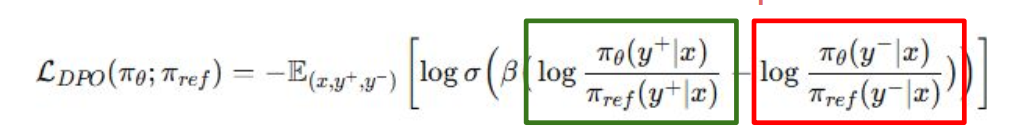

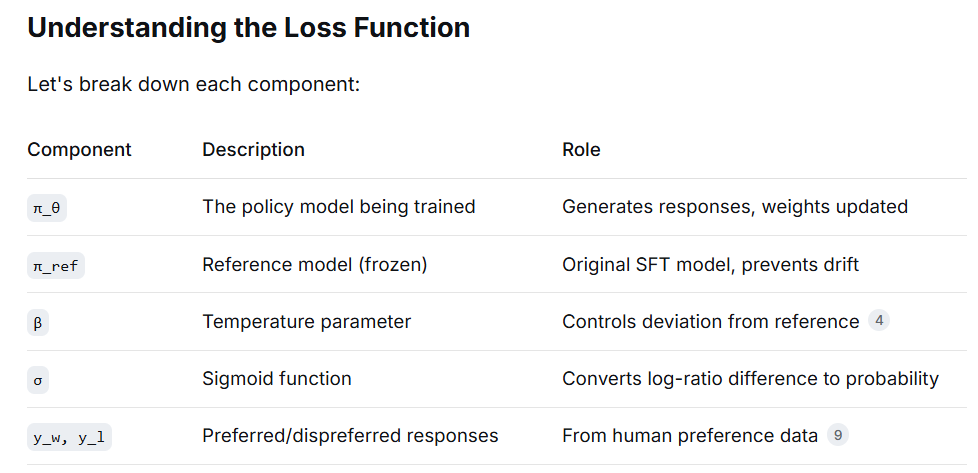

In [11]:
#Complete DPO Demo from Scratch

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import Dataset
from torch.utils.data import DataLoader
import numpy as np

class DPOTrainer:
    """
    Direct Preference Optimization Trainer from Scratch
    """
    def __init__(
        self,
        model_name: str = "gpt2",
        beta: float = 0.1,  # KL penalty coefficient
        learning_rate: float = 5e-6,
        batch_size: int = 4
    ):
        # Load model and tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token

        # Policy model (trainable)
        self.policy_model = AutoModelForCausalLM.from_pretrained(model_name)

        # Reference model (frozen)
        self.ref_model = AutoModelForCausalLM.from_pretrained(model_name)
        for param in self.ref_model.parameters():
            param.requires_grad = False

        # Move to device
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_model = self.policy_model.to(self.device)
        self.ref_model = self.ref_model.to(self.device)

        # Hyperparameters
        self.beta = beta
        self.optimizer = torch.optim.AdamW(
            self.policy_model.parameters(),
            lr=learning_rate
        )
        self.batch_size = batch_size

    def prepare_preference_data(self):
        """
        Create synthetic preference dataset
        In practice, this would come from human annotations
        """
        # Format: prompt, chosen_response (preferred), rejected_response
        data = [
            {
                "prompt": "Explain quantum computing",
                "chosen": "Quantum computing uses qubits that can exist in superposition, allowing parallel computation.",
                "rejected": "Quantum computing is complicated stuff with physics and computers."
            },
            {
                "prompt": "How do I learn Python?",
                "chosen": "Start with basic syntax, then practice with small projects. Online platforms like Codecademy are great.",
                "rejected": "Just read a book and you'll learn."
            },
            {
                "prompt": "What's the capital of France?",
                "chosen": "The capital of France is Paris, known for its cultural landmarks like the Eiffel Tower.",
                "rejected": "idk probably Paris"
            },
            {
                "prompt": "Explain photosynthesis",
                "chosen": "Photosynthesis is how plants convert sunlight, water and CO2 into energy, producing oxygen as a byproduct.",
                "rejected": "plants eat sun"
            },
            {
                "prompt": "How to stay healthy?",
                "chosen": "Maintain a balanced diet, exercise regularly, get adequate sleep, and manage stress.",
                "rejected": "eat less move more"
            },
            {
                "prompt": "What is machine learning?",
                "chosen": "Machine learning is a subset of AI where systems learn patterns from data to make predictions.",
                "rejected": "computers learning stuff"
            }
        ]
        return Dataset.from_list(data)

    def compute_log_probs(self, model, input_ids, attention_mask, labels):
        """
        Compute log probabilities for given sequences
        """
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Shift for next token prediction
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        # Compute log probabilities
        log_probs = -F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            reduction='none'
        )
        log_probs = log_probs.view(shift_labels.shape)

        # Mask padding tokens
        mask = (shift_labels != self.tokenizer.pad_token_id).float()
        log_probs = (log_probs * mask).sum(dim=1) / mask.sum(dim=1)

        return log_probs

    def dpo_loss(self, policy_chosen_logps, policy_rejected_logps,
                 ref_chosen_logps, ref_rejected_logps):
        """
        Compute DPO loss
        L = -log σ(β * (log(π(y_w)/π_ref(y_w)) - log(π(y_l)/π_ref(y_l))))
        """
        # Compute log ratios
        chosen_log_ratio = policy_chosen_logps - ref_chosen_logps
        rejected_log_ratio = policy_rejected_logps - ref_rejected_logps

        # Compute logits (β * difference in log ratios)
        logits = self.beta * (chosen_log_ratio - rejected_log_ratio)

        # Apply sigmoid and compute loss
        loss = -F.logsigmoid(logits).mean()

        # Compute accuracy (how often chosen > rejected)
        with torch.no_grad():
            accuracy = (logits > 0).float().mean()

        return loss, accuracy

    def train_step(self, batch):
        """
        Single training step
        """
        # Tokenize all sequences
        def tokenize_responses(prompts, responses):
            texts = [f"### Prompt:\n{p}\n### Response:\n{r}"
                     for p, r in zip(prompts, responses)]
            return self.tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(self.device)

        # Get tokenized inputs
        chosen_tokens = tokenize_responses(batch['prompt'], batch['chosen'])
        rejected_tokens = tokenize_responses(batch['prompt'], batch['rejected'])

        # Compute log probs for policy model
        policy_chosen_logps = self.compute_log_probs(
            self.policy_model,
            chosen_tokens['input_ids'],
            chosen_tokens['attention_mask'],
            chosen_tokens['input_ids']
        )

        policy_rejected_logps = self.compute_log_probs(
            self.policy_model,
            rejected_tokens['input_ids'],
            rejected_tokens['attention_mask'],
            rejected_tokens['input_ids']
        )

        # Compute log probs for reference model (no gradients)
        with torch.no_grad():
            ref_chosen_logps = self.compute_log_probs(
                self.ref_model,
                chosen_tokens['input_ids'],
                chosen_tokens['attention_mask'],
                chosen_tokens['input_ids']
            )

            ref_rejected_logps = self.compute_log_probs(
                self.ref_model,
                rejected_tokens['input_ids'],
                rejected_tokens['attention_mask'],
                rejected_tokens['input_ids']
            )

        # Compute loss
        loss, accuracy = self.dpo_loss(
            policy_chosen_logps, policy_rejected_logps,
            ref_chosen_logps, ref_rejected_logps
        )

        # Backward pass
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), 1.0)
        self.optimizer.step()

        return loss.item(), accuracy.item()

    def train(self, num_epochs=3):
        """
        Full training loop
        """
        # Load and prepare data
        dataset = self.prepare_preference_data()
        dataloader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=True
        )

        print(f"Starting DPO training with β={self.beta}")
        print("-" * 60)

        for epoch in range(num_epochs):
            total_loss = 0
            total_acc = 0
            num_batches = 0

            for batch in dataloader:
                loss, acc = self.train_step(batch)
                total_loss += loss
                total_acc += acc
                num_batches += 1

                if num_batches % 5 == 0:
                    print(f"Step {num_batches}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")

            avg_loss = total_loss / num_batches
            avg_acc = total_acc / num_batches
            print(f"Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}, Avg Accuracy = {avg_acc:.4f}")
            print("-" * 60)

    def generate_response(self, prompt):
        """
        Generate response with the trained model
        """
        input_text = f"### Prompt:\n{prompt}\n### Response:\n"
        inputs = self.tokenizer(input_text, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.policy_model.generate(
                inputs.input_ids,
                max_new_tokens=100,
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        # Extract just the response part
        if "### Response:\n" in response:
            response = response.split("### Response:\n")[-1]
        return response

# Run DPO training
print("DPO FROM SCRATCH DEMO")
print("=" * 60)

# Initialize trainer
trainer = DPOTrainer(
    model_name="gpt2",
    beta=0.1,  # Lower beta = more aggressive adaptation
    learning_rate=5e-6,
    batch_size=2
)

# Test before DPO
print("\nBEFORE DPO:")
print("-" * 60)
test_prompts = [
    "Explain quantum computing",
    "How to stay healthy?"
]

for prompt in test_prompts:
    response = trainer.generate_response(prompt)
    print(f"Prompt: {prompt}")
    print(f"Response: {response}")
    print()

# Train with DPO
print("\nTRAINING WITH DPO...")
print("=" * 60)
trainer.train(num_epochs=5)

# Test after DPO
print("\nAFTER DPO:")
print("-" * 60)
for prompt in test_prompts:
    response = trainer.generate_response(prompt)
    print(f"Prompt: {prompt}")
    print(f"Response: {response}")
    print()

DPO FROM SCRATCH DEMO


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


BEFORE DPO:
------------------------------------------------------------
Prompt: Explain quantum computing
Response: You can start to do it.

Prompt: How to stay healthy?
Response: It's important to take a rest and rest once a day. It is important to keep your body in a good, comfortable state.
### Exercise is important for your skin and eyes. It helps to increase your absorption of the minerals from your body and from the water you


TRAINING WITH DPO...
Starting DPO training with β=0.1
------------------------------------------------------------
Epoch 1: Avg Loss = 0.6906, Avg Accuracy = 0.6667
------------------------------------------------------------
Epoch 2: Avg Loss = 0.6764, Avg Accuracy = 1.0000
------------------------------------------------------------
Epoch 3: Avg Loss = 0.6613, Avg Accuracy = 1.0000
------------------------------------------------------------
Epoch 4: Avg Loss = 0.6451, Avg Accuracy = 1.0000
------------------------------------------------------------
E

In [12]:
#Advanced: DPO with LoRA for Efficiency

from peft import LoraConfig, get_peft_model

class DPOTrainerWithLoRA(DPOTrainer):
    """
    DPO Trainer with LoRA for parameter-efficient fine-tuning
    """
    def __init__(self, *args, lora_r=8, lora_alpha=16, **kwargs):
        super().__init__(*args, **kwargs)

        # Apply LoRA to policy model
        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            target_modules=["c_attn", "c_proj"],  # For GPT2
            lora_dropout=0.1,
            bias="none",
            task_type="CAUSAL_LM"
        )

        self.policy_model = get_peft_model(self.policy_model, lora_config)

        # Print trainable parameters
        trainable_params = sum(p.numel() for p in self.policy_model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.policy_model.parameters())
        print(f"LoRA trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

        # Reinitialize optimizer for LoRA parameters
        self.optimizer = torch.optim.AdamW(
            self.policy_model.parameters(),
            lr=kwargs.get('learning_rate', 5e-6)
        )

# Usage
lora_trainer = DPOTrainerWithLoRA(
    model_name="gpt2",
    beta=0.1,
    lora_r=8,
    learning_rate=1e-5
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

LoRA trainable parameters: 811,008 (0.65%)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Understanding the Beta Parameter

The β parameter controls the trade-off between preference optimization and staying close to the reference model

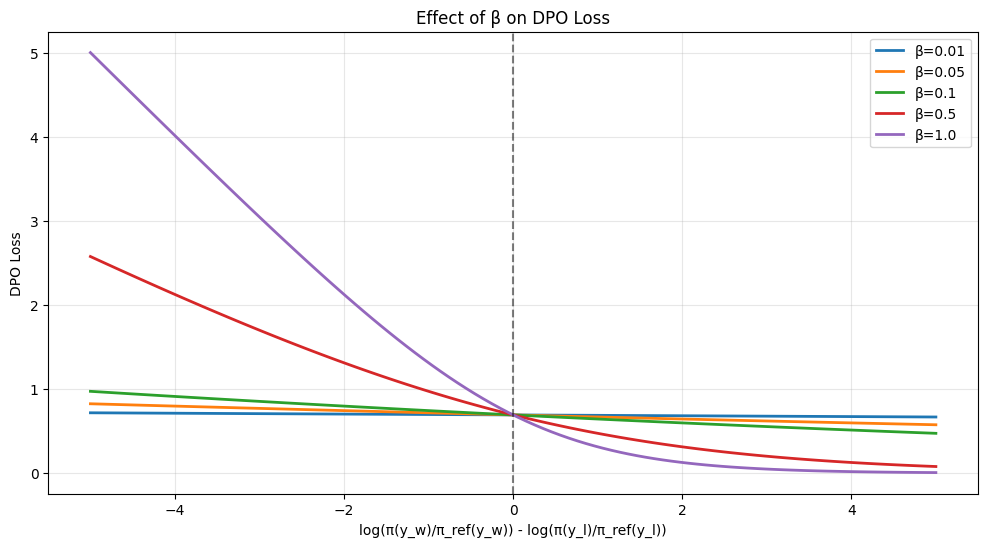

In [13]:
def visualize_beta_effect():
    """
    Demonstrate how beta affects the loss landscape
    """
    import matplotlib.pyplot as plt
    import numpy as np

    beta_values = [0.01, 0.05, 0.1, 0.5, 1.0]

    # Simulate log ratios
    log_ratio_diff = np.linspace(-5, 5, 100)

    plt.figure(figsize=(12, 6))

    for beta in beta_values:
        # DPO loss = -log σ(β * diff)
        loss = -np.log(1 / (1 + np.exp(-beta * log_ratio_diff)))
        plt.plot(log_ratio_diff, loss, label=f'β={beta}', linewidth=2)

    plt.xlabel('log(π(y_w)/π_ref(y_w)) - log(π(y_l)/π_ref(y_l))')
    plt.ylabel('DPO Loss')
    plt.title('Effect of β on DPO Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    plt.show()

visualize_beta_effect()

Data Format for DPO

DPO requires preference data in a specific format

In [14]:
# Standard format for DPO datasets
dpo_data = [
    {
        "prompt": "What is the capital of France?",
        "chosen": "The capital of France is Paris, which is known for its cultural heritage and landmarks like the Eiffel Tower.",
        "rejected": "idk maybe Paris?"
    },
    {
        "prompt": "Explain photosynthesis",
        "chosen": "Photosynthesis is the process where plants convert sunlight, water, and carbon dioxide into glucose and oxygen.",
        "rejected": "plants use sun to make food"
    }
]

# Save as JSONL for training
import json
with open('dpo_data.jsonl', 'w') as f:
    for item in dpo_data:
        f.write(json.dumps(item) + '\n')

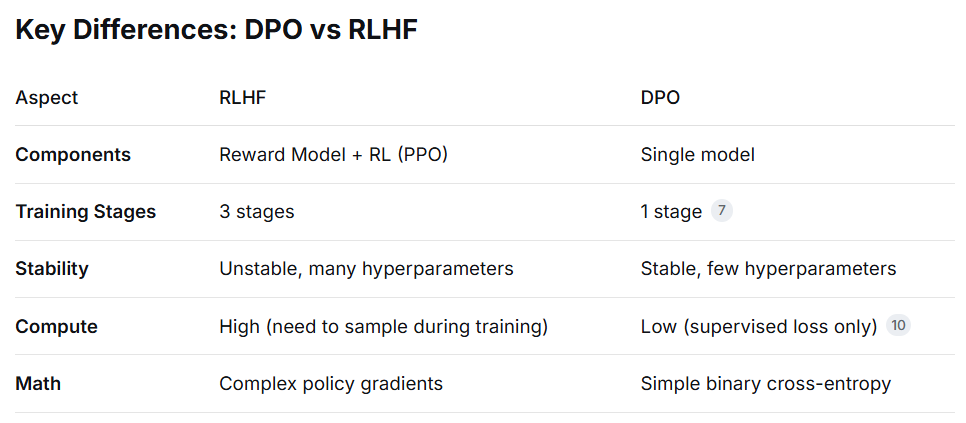

When to Use DPO

Good for:

Fine-tuning on human preference data

Style transfer (e.g., making responses more polite)

Safety alignment (reducing harmful outputs)

Small to medium datasets (100-10,000 examples)

Not ideal for:

Tasks requiring online exploration

When you need explicit reward values

Very large preference datasets (RLHF may scale better)

---
## ✅ TASK 1 — Supervised Fine-Tuning (Full Fine-Tuning) — Dataset Size Fix

**Original problem:** Only 4 training examples — too few to learn general patterns.

**Fix applied (Approach 1 — Dataset Size):** Expand to 21 customer-service examples covering 7 diverse topics. The backbone code structure follows Cell 12 of the original notebook, with the larger dataset substituted in.

**What changes:**
- `training_data` now has 21 examples across 7 categories (password, orders, returns, tech, products, shipping, account)
- `format_data()` stores `prompt_length` so labels for the instruction portion can be masked to `-100`
- `TrainingArguments` uses a realistic learning rate and epoch count
- A 80/20 train/eval split lets us track both `train_loss` and `eval_loss` per epoch


In [15]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from datasets import Dataset
import numpy as np

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Model & tokenizer ─────────────────────────────────────────────────────────
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForCausalLM.from_pretrained(model_name)
model     = model.to(device)
tokenizer.pad_token = tokenizer.eos_token

# ── FIX 1: LARGER, MORE DIVERSE DATASET (21 examples, 7 categories) ──────────
training_data = [
    # Password / Account
    {"instruction": "How do I reset my password?",
     "response": "To reset your password, click 'Forgot Password' on the login page. You'll receive a reset link via email within 5 minutes."},
    {"instruction": "I forgot my username",
     "response": "Your username is the email address you used to register. If you're still having trouble, contact support with your phone number."},
    {"instruction": "Can I change my email address?",
     "response": "Yes, go to Account Settings > Profile > Email. You'll need to verify the new email address before the change takes effect."},

    # Order issues
    {"instruction": "My order hasn't arrived yet",
     "response": "I apologize for the delay. Please provide your order number and I'll track it immediately. Delivery typically takes 3-5 business days."},
    {"instruction": "Where is my package?",
     "response": "You can track your package using the tracking link in your shipping confirmation email. If you need assistance, share your order number."},
    {"instruction": "Can I cancel my order?",
     "response": "Orders can be cancelled within 1 hour of placement. Please check your order status in your account or contact support immediately."},

    # Returns / Refunds
    {"instruction": "What's your return policy?",
     "response": "We offer 30-day returns for unused items in original packaging. Print a return label from your account or contact support."},
    {"instruction": "How long do refunds take?",
     "response": "Refunds process within 5-7 business days after we receive your return. The time for funds to appear depends on your bank."},
    {"instruction": "I received a damaged item",
     "response": "I'm sorry to hear that. Please send photos of the damage to support@company.com with your order number, and we'll replace it immediately."},

    # Technical issues
    {"instruction": "The app keeps crashing",
     "response": "Let's troubleshoot: 1) Update to latest version 2) Clear app cache 3) Reinstall. If issues persist, share your device model and OS."},
    {"instruction": "Website is slow",
     "response": "Try clearing your browser cache or using incognito mode. If the issue continues, please let us know your browser version and location."},
    {"instruction": "Payment not working",
     "response": "Ensure your card details are correct and you have sufficient funds. Try a different payment method or contact your bank."},

    # Product questions
    {"instruction": "Do you have this in blue?",
     "response": "The blue variant is currently in stock! Check product page for size availability. We also have navy and sky blue options."},
    {"instruction": "What's the size chart?",
     "response": "Our size chart is available on each product page. For custom sizing, please provide your measurements and we'll recommend the best fit."},
    {"instruction": "Is this waterproof?",
     "response": "This item has water-resistant coating but isn't fully waterproof. It can handle light rain but shouldn't be submerged."},

    # Shipping
    {"instruction": "Do you ship internationally?",
     "response": "Yes, we ship to over 50 countries. Shipping costs and delivery times vary by location. Check our shipping policy for details."},
    {"instruction": "How much is shipping?",
     "response": "Standard shipping is free on orders over $50. Otherwise, it's $5.99. Express shipping options are available at checkout."},
    {"instruction": "Express shipping options",
     "response": "We offer 2-day express ($12.99) and next-day ($24.99) shipping. Orders must be placed by 2 PM for next-day delivery."},

    # Account management
    {"instruction": "Delete my account",
     "response": "To delete your account, go to Settings > Privacy > Delete Account. This action is permanent and cannot be undone."},
    {"instruction": "Update payment method",
     "response": "You can update payment methods in Account > Payment Methods. Add a new card or remove old ones for future purchases."},
    {"instruction": "Subscription not working",
     "response": "Check your subscription status in Account > Subscriptions. If payments are failing, update your payment method or contact support."},
]

print(f"Dataset size: {len(training_data)} examples (was 4 in original)")

# ── Format data — store prompt length for label masking ───────────────────────
def format_data(example):
    prompt     = f"Instruction: {example['instruction']}\nResponse: "
    completion = f"{example['response']}"
    full_text  = prompt + completion
    return {
        "text":          full_text,
        "prompt_length": len(tokenizer.encode(prompt))
    }

formatted_data = [format_data(item) for item in training_data]
full_dataset   = Dataset.from_list(formatted_data)

# ── 80/20 train / eval split (for loss tracking) ──────────────────────────────
split       = full_dataset.train_test_split(test_size=0.2, seed=42)
train_ds    = split["train"]
eval_ds     = split["test"]
print(f"Train: {len(train_ds)} | Eval: {len(eval_ds)}")

# ── Tokenise — mask instruction tokens in labels ──────────────────────────────
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    # Mask instruction part so loss is only computed on the response
    for i, prompt_len in enumerate(examples["prompt_length"]):
        tokenized["labels"][i, :prompt_len] = -100
    return tokenized

train_tokenized = train_ds.map(tokenize_function, batched=True,
                               remove_columns=["text", "prompt_length"])
eval_tokenized  = eval_ds.map(tokenize_function, batched=True,
                              remove_columns=["text", "prompt_length"])

# ── Training arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./task1_sft_model",
    num_train_epochs            = 5,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    logging_dir                 = "./task1_logs",
    logging_steps               = 5,
    eval_strategy               = "epoch",   # evaluate after each epoch
    save_strategy               = "epoch",
    save_total_limit            = 2,
    learning_rate               = 3e-5,
    weight_decay                = 0.01,
    warmup_steps                = 10,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    fp16                        = torch.cuda.is_available(),
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_tokenized,
    eval_dataset  = eval_tokenized,
    data_collator = data_collator,
)

# ── Train ─────────────────────────────────────────────────────────────────────
print("\n=== Task 1: Starting SFT training ===")
trainer.train()
print("Training complete!")

# ── Save ──────────────────────────────────────────────────────────────────────
model.save_pretrained("./task1_sft_final")
tokenizer.save_pretrained("./task1_sft_final")
print("Model saved to ./task1_sft_final")


Using device: cpu


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Dataset size: 21 examples (was 4 in original)
Train: 16 | Eval: 5


Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./task1_sft_final


In [16]:
# ── Before / After comparison ─────────────────────────────────────────────────
original_model   = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)
finetuned_model  = AutoModelForCausalLM.from_pretrained("./task1_sft_final").to(device)

def test_model(mdl, tkz, instruction, dev):
    prompt = f"Instruction: {instruction}\nResponse: "
    inputs = tkz(prompt, return_tensors="pt")
    inputs = {k: v.to(dev) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = mdl.generate(
            inputs["input_ids"],
            attention_mask = inputs.get("attention_mask"),
            max_new_tokens = 60,
            temperature    = 0.7,
            do_sample      = True,
            pad_token_id   = tkz.pad_token_id
        )
    return tkz.decode(outputs[0], skip_special_tokens=True)

test_questions = [
    "How do I reset my password?",
    "What's your return policy?",
    "My order hasn't arrived yet"
]

print("BEFORE FINE-TUNING:")
print("-" * 60)
for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {test_model(original_model, tokenizer, q, device)}")
    print()

print("\nAFTER FINE-TUNING (Task 1 - SFT):")
print("-" * 60)
for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {test_model(finetuned_model, tokenizer, q, device)}")
    print()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

BEFORE FINE-TUNING:
------------------------------------------------------------
Q: How do I reset my password?
A: Instruction: How do I reset my password?
Response: _______________________________________________
I don't think I've got any problems with this code.
I don't think this is particularly useful for the user, but I think it would be helpful to replace the password in case of a malicious update.
Conclusion
We're not going to be able to complete

Q: What's your return policy?
A: Instruction: What's your return policy?
Response: -------------
The following is the following, from The New Yorker:
The original paper, in which I write about the current administration's "reform" of the Supreme Court, called the Supreme Court's "reform" of the Supreme Court, and said that it would take seven to eight years

Q: My order hasn't arrived yet
A: Instruction: My order hasn't arrived yet
Response: ???????????????
In the meantime, I will be happy to announce my order as a gift!
My message to

---
## ✅ TASK 2 — Parameter-Efficient Fine-Tuning with LoRA — Dataset Size Fix

**Original problem (Cell 34 backbone):** Single example dataset; model is phi-2 which is too large for most demo environments.

**Fix applied (Approach 1 — Dataset Size):** Same 21-example customer-service dataset, but now adapted with LoRA on distilgpt2.  
The backbone follows Cell 34 & 37 of the original notebook (LoraConfig + get_peft_model + Trainer), scaled to the customer-service task.

**What changes:**
- `training_data` expands to 21 examples (same as Task 1)
- Model changed to `distilgpt2` (c_attn / c_proj are the correct target modules for GPT-2 architecture)
- Only LoRA adapter weights are trained (~0.3% of parameters)
- 80/20 train/eval split and `eval_strategy="epoch"` for loss tracking


In [17]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Base model & tokenizer (distilgpt2 — small enough for CPU demo) ───────────
model_name = "distilgpt2"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(model_name)
base_model = base_model.to(device)

# ── LoRA config (backbone from Cell 34) ──────────────────────────────────────
# distilgpt2 uses 'c_attn' and 'c_proj' as the attention projection layers
lora_config = LoraConfig(
    r              = 8,          # rank
    lora_alpha     = 16,         # scaling factor
    target_modules = ["c_attn", "c_proj"],  # GPT-2 attention projections
    lora_dropout   = 0.1,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

# ── FIX 1: LARGER CUSTOMER-SERVICE DATASET (21 examples) ─────────────────────
training_data = [
    # Password / Account
    {"instruction": "How do I reset my password?",
     "response": "To reset your password, click 'Forgot Password' on the login page. You'll receive a reset link via email within 5 minutes."},
    {"instruction": "I forgot my username",
     "response": "Your username is the email address you used to register. If you're still having trouble, contact support with your phone number."},
    {"instruction": "Can I change my email address?",
     "response": "Yes, go to Account Settings > Profile > Email. You'll need to verify the new email address before the change takes effect."},
    # Orders
    {"instruction": "My order hasn't arrived yet",
     "response": "I apologize for the delay. Please provide your order number and I'll track it immediately. Delivery typically takes 3-5 business days."},
    {"instruction": "Where is my package?",
     "response": "You can track your package using the tracking link in your shipping confirmation email. If you need assistance, share your order number."},
    {"instruction": "Can I cancel my order?",
     "response": "Orders can be cancelled within 1 hour of placement. Please check your order status in your account or contact support immediately."},
    # Returns / Refunds
    {"instruction": "What's your return policy?",
     "response": "We offer 30-day returns for unused items in original packaging. Print a return label from your account or contact support."},
    {"instruction": "How long do refunds take?",
     "response": "Refunds process within 5-7 business days after we receive your return. The time for funds to appear depends on your bank."},
    {"instruction": "I received a damaged item",
     "response": "I'm sorry to hear that. Please send photos of the damage to support@company.com with your order number, and we'll replace it immediately."},
    # Technical
    {"instruction": "The app keeps crashing",
     "response": "Let's troubleshoot: 1) Update to latest version 2) Clear app cache 3) Reinstall. If issues persist, share your device model and OS."},
    {"instruction": "Website is slow",
     "response": "Try clearing your browser cache or using incognito mode. If the issue continues, please let us know your browser version and location."},
    {"instruction": "Payment not working",
     "response": "Ensure your card details are correct and you have sufficient funds. Try a different payment method or contact your bank."},
    # Products
    {"instruction": "Do you have this in blue?",
     "response": "The blue variant is currently in stock! Check product page for size availability. We also have navy and sky blue options."},
    {"instruction": "What's the size chart?",
     "response": "Our size chart is available on each product page. For custom sizing, please provide your measurements and we'll recommend the best fit."},
    {"instruction": "Is this waterproof?",
     "response": "This item has water-resistant coating but isn't fully waterproof. It can handle light rain but shouldn't be submerged."},
    # Shipping
    {"instruction": "Do you ship internationally?",
     "response": "Yes, we ship to over 50 countries. Shipping costs and delivery times vary by location. Check our shipping policy for details."},
    {"instruction": "How much is shipping?",
     "response": "Standard shipping is free on orders over $50. Otherwise, it's $5.99. Express shipping options are available at checkout."},
    {"instruction": "Express shipping options",
     "response": "We offer 2-day express ($12.99) and next-day ($24.99) shipping. Orders must be placed by 2 PM for next-day delivery."},
    # Account management
    {"instruction": "Delete my account",
     "response": "To delete your account, go to Settings > Privacy > Delete Account. This action is permanent and cannot be undone."},
    {"instruction": "Update payment method",
     "response": "You can update payment methods in Account > Payment Methods. Add a new card or remove old ones for future purchases."},
    {"instruction": "Subscription not working",
     "response": "Check your subscription status in Account > Subscriptions. If payments are failing, update your payment method or contact support."},
]

print(f"Dataset size: {len(training_data)} examples")

# ── Format and tokenise ───────────────────────────────────────────────────────
def format_data(example):
    prompt    = f"Instruction: {example['instruction']}\nResponse: "
    full_text = prompt + example['response']
    return {"text": full_text, "prompt_length": len(tokenizer.encode(prompt))}

formatted_data = [format_data(item) for item in training_data]
full_dataset   = Dataset.from_list(formatted_data)
split          = full_dataset.train_test_split(test_size=0.2, seed=42)

def tokenize_fn(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation  = True,
        padding     = "max_length",
        max_length  = 128,
        return_tensors = "pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    for i, pl in enumerate(examples["prompt_length"]):
        tokenized["labels"][i, :pl] = -100   # mask instruction tokens
    return tokenized

train_tok = split["train"].map(tokenize_fn, batched=True,
                               remove_columns=["text", "prompt_length"])
eval_tok  = split["test"].map(tokenize_fn, batched=True,
                              remove_columns=["text", "prompt_length"])

# ── Training arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./task2_lora_model",
    num_train_epochs            = 5,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    logging_steps               = 5,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    learning_rate               = 2e-4,   # higher LR works well for LoRA
    weight_decay                = 0.01,
    warmup_steps                = 10,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    fp16                        = torch.cuda.is_available(),
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model         = peft_model,
    args          = training_args,
    train_dataset = train_tok,
    eval_dataset  = eval_tok,
    data_collator = data_collator,
)

# ── Train ─────────────────────────────────────────────────────────────────────
print("\n=== Task 2: Starting LoRA SFT training ===")
trainer.train()
print("LoRA training complete!")

# ── Save only the small LoRA adapter weights ──────────────────────────────────
peft_model.save_pretrained("./task2_lora_weights")
tokenizer.save_pretrained("./task2_lora_weights")
print("LoRA weights saved to ./task2_lora_weights")


Using device: cpu


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 405,504 || all params: 82,318,080 || trainable%: 0.4926
Dataset size: 21 examples


Map:   0%|          | 0/16 [00:00<?, ? examples/s]

...


=== Task 2: Starting LoRA SFT training ===


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,4.019787
2,3.940774,3.997134
3,4.059640,3.932954
4,3.800361,3.865617
5,3.791758,3.835277


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
mtime may not be reliable on this filesystem, falling back to numerical ordering
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' arg

LoRA training complete!
LoRA weights saved to ./task2_lora_weights


In [18]:
# ── Load and test the LoRA model ──────────────────────────────────────────────
from peft import PeftModel

base_for_test = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)
lora_loaded   = PeftModel.from_pretrained(base_for_test, "./task2_lora_weights").to(device)

# Optionally merge for pure-inference speed (no LoRA overhead at inference)
merged_model = lora_loaded.merge_and_unload()
merged_model.eval()

def test_lora_model(mdl, tkz, instruction, dev):
    prompt = f"Instruction: {instruction}\nResponse: "
    inputs = tkz(prompt, return_tensors="pt")
    inputs = {k: v.to(dev) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = mdl.generate(
            inputs["input_ids"],
            attention_mask = inputs.get("attention_mask"),
            max_new_tokens = 60,
            temperature    = 0.7,
            do_sample      = True,
            pad_token_id   = tkz.pad_token_id
        )
    return tkz.decode(outputs[0], skip_special_tokens=True)

test_questions = [
    "How do I reset my password?",
    "What's your return policy?",
    "My order hasn't arrived yet"
]

base_only = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)
print("BASE MODEL (no fine-tuning):")
print("-" * 60)
for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {test_lora_model(base_only, tokenizer, q, device)}")
    print()

print("\nAFTER LoRA FINE-TUNING (Task 2):")
print("-" * 60)
for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {test_lora_model(merged_model, tokenizer, q, device)}")
    print()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

BASE MODEL (no fine-tuning):
------------------------------------------------------------
Q: How do I reset my password?
A: Instruction: How do I reset my password?
Response: ~~~~~
Answer: ~~~~~
Example: You can reset my password once you reset the password.
Example: You can reset my password once you reset the password. ~~~~~
Example: You can reset my password once you reset the password. ~~~~~
Example: You

Q: What's your return policy?
A: Instruction: What's your return policy?
Response: ____________________________________________________________________________________
The following is a general description of the policy:
In the coming weeks, the following posts will be revisited on the following topics:
What are the best options for the new EU policy?
What are the benefits of EU membership?
What are the risks of implementing

Q: My order hasn't arrived yet
A: Instruction: My order hasn't arrived yet
Response: _______________________________________________________________
Hi, I a

---
## ✅ TASK 3 — Direct Preference Optimization (DPO) — Dataset Size Fix

**Original problem (Cell 50 backbone):** Only 6 generic preference pairs; model is gpt2.

**Fix applied (Approach 1 — Dataset Size):** Expand to 21 customer-service preference pairs covering the same 7 categories used in Tasks 1 & 2.  
Each pair has a `chosen` (helpful, specific) response and a `rejected` (vague or unhelpful) response.

**What changes:**
- `prepare_preference_data()` now returns 21 pairs instead of 6
- Data split: 80% train / 20% eval — `eval_accuracy` is printed after each epoch
- `DPOTrainer` backbone from Cell 50 is preserved; only the dataset method and the epoch loop are extended with eval logic


In [19]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import Dataset
from torch.utils.data import DataLoader
import numpy as np

# ────────────────────────────────────────────────────────────────────────────
# DPO Trainer class — backbone from Cell 50, dataset expanded (Task 3 fix)
# ────────────────────────────────────────────────────────────────────────────
class DPOTrainer:
    """
    Direct Preference Optimization Trainer.
    Backbone from original notebook Cell 50;
    preference data expanded to 21 customer-service pairs.
    """
    def __init__(
        self,
        model_name    : str   = "gpt2",
        beta          : float = 0.1,
        learning_rate : float = 5e-6,
        batch_size    : int   = 4
    ):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.policy_model = AutoModelForCausalLM.from_pretrained(model_name)
        self.ref_model    = AutoModelForCausalLM.from_pretrained(model_name)
        for param in self.ref_model.parameters():
            param.requires_grad = False

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_model = self.policy_model.to(self.device)
        self.ref_model    = self.ref_model.to(self.device)

        self.beta       = beta
        self.batch_size = batch_size
        self.optimizer  = torch.optim.AdamW(
            self.policy_model.parameters(), lr=learning_rate
        )

    # ── FIX 1: LARGER CUSTOMER-SERVICE PREFERENCE DATASET (21 pairs) ──────────
    def prepare_preference_data(self):
        """
        21 customer-service preference pairs across 7 topics.
        chosen  = specific, helpful, professional response
        rejected = vague or unhelpful response
        """
        data = [
            # Password / Account
            {"prompt": "How do I reset my password?",
             "chosen":   "Click 'Forgot Password' on the login page. A reset link will arrive in your email within 5 minutes.",
             "rejected": "Look for a reset option somewhere on the site."},
            {"prompt": "I forgot my username",
             "chosen":   "Your username is the email address you registered with. Contact support with your phone number if you still need help.",
             "rejected": "Try guessing it or create a new account."},
            {"prompt": "Can I change my email address?",
             "chosen":   "Yes. Go to Account Settings > Profile > Email and verify the new address before the change takes effect.",
             "rejected": "Maybe, check your account settings."},

            # Orders
            {"prompt": "My order hasn't arrived yet",
             "chosen":   "I apologize for the delay. Please share your order number so I can track it immediately—delivery typically takes 3-5 business days.",
             "rejected": "Shipping takes time. Just wait a bit longer."},
            {"prompt": "Where is my package?",
             "chosen":   "Use the tracking link in your shipping confirmation email. Share your order number if you need more help.",
             "rejected": "It's probably on its way. Check back later."},
            {"prompt": "Can I cancel my order?",
             "chosen":   "Orders can be cancelled within 1 hour of placement. Check your order status in your account or contact support right away.",
             "rejected": "Maybe if you're fast enough."},

            # Returns / Refunds
            {"prompt": "What's your return policy?",
             "chosen":   "We offer 30-day returns for unused items in original packaging. Print a return label from your account or contact support.",
             "rejected": "You can return stuff within some time period."},
            {"prompt": "How long do refunds take?",
             "chosen":   "Refunds process within 5-7 business days after we receive your return. Your bank may take additional time to show the funds.",
             "rejected": "Refunds take a while, depends on many things."},
            {"prompt": "I received a damaged item",
             "chosen":   "I'm sorry about that. Email photos of the damage to support@company.com with your order number and we'll send a replacement immediately.",
             "rejected": "That's unfortunate. File a complaint and we'll see what we can do."},

            # Technical
            {"prompt": "The app keeps crashing",
             "chosen":   "Try: 1) Update to the latest version 2) Clear the app cache 3) Reinstall. Share your device model and OS if the problem continues.",
             "rejected": "Apps crash sometimes. Restart your phone."},
            {"prompt": "Website is slow",
             "chosen":   "Clear your browser cache or try incognito mode. If it persists, let us know your browser version and location.",
             "rejected": "Our servers might be busy. Try again later."},
            {"prompt": "Payment not working",
             "chosen":   "Double-check your card details and available funds. Try a different payment method or contact your bank for assistance.",
             "rejected": "Payment issues happen. Try a different card."},

            # Products
            {"prompt": "Do you have this in blue?",
             "chosen":   "The blue variant is in stock! Check the product page for size availability. Navy and sky blue options are also available.",
             "rejected": "I think we have blue. Check the website."},
            {"prompt": "What's the size chart?",
             "chosen":   "The size chart is on each product page. For a custom recommendation, share your measurements and we'll advise the best fit.",
             "rejected": "Sizes are on the website somewhere."},
            {"prompt": "Is this waterproof?",
             "chosen":   "The item has a water-resistant coating—fine for light rain but not for submersion. For fully waterproof options, see our outdoor range.",
             "rejected": "It can handle some water I think."},

            # Shipping
            {"prompt": "Do you ship internationally?",
             "chosen":   "Yes, we ship to over 50 countries. Costs and delivery times vary by location—check our shipping policy page for details.",
             "rejected": "We ship to some countries, not sure which ones."},
            {"prompt": "How much is shipping?",
             "chosen":   "Standard shipping is free on orders over $50; otherwise $5.99. Express options are shown at checkout.",
             "rejected": "Shipping costs money. It varies."},
            {"prompt": "Express shipping options",
             "chosen":   "We offer 2-day express ($12.99) and next-day ($24.99). Place your order by 2 PM for next-day eligibility.",
             "rejected": "Express shipping is faster but costs more."},

            # Account management
            {"prompt": "Delete my account",
             "chosen":   "Go to Settings > Privacy > Delete Account. This is permanent and cannot be undone. Download your data first if needed.",
             "rejected": "You can delete it in settings somewhere."},
            {"prompt": "Update payment method",
             "chosen":   "Navigate to Account > Payment Methods to add a new card or remove an old one for future purchases.",
             "rejected": "Look for payment settings in your account."},
            {"prompt": "Subscription not working",
             "chosen":   "Check your subscription status under Account > Subscriptions. If payments are failing, update your payment method or contact support.",
             "rejected": "Subscriptions can be finicky. Try logging out and back in."},
        ]
        full_ds = Dataset.from_list(data)
        # 80/20 split for train/eval
        split = full_ds.train_test_split(test_size=0.2, seed=42)
        return split["train"], split["test"]

    def compute_log_probs(self, model, input_ids, attention_mask, labels):
        outputs     = model(input_ids=input_ids, attention_mask=attention_mask)
        logits      = outputs.logits
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        log_probs    = -F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            reduction='none'
        )
        log_probs = log_probs.view(shift_labels.shape)
        mask      = (shift_labels != self.tokenizer.pad_token_id).float()
        log_probs = (log_probs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return log_probs

    def dpo_loss(self, policy_chosen_logps, policy_rejected_logps,
                 ref_chosen_logps, ref_rejected_logps):
        chosen_log_ratio   = policy_chosen_logps   - ref_chosen_logps
        rejected_log_ratio = policy_rejected_logps - ref_rejected_logps
        logits  = self.beta * (chosen_log_ratio - rejected_log_ratio)
        loss    = -F.logsigmoid(logits).mean()
        with torch.no_grad():
            accuracy = (logits > 0).float().mean()
        return loss, accuracy

    def train_step(self, batch):
        def tokenize_responses(prompts, responses):
            texts = [f"### Prompt:\n{p}\n### Response:\n{r}"
                     for p, r in zip(prompts, responses)]
            return self.tokenizer(
                texts, padding=True, truncation=True,
                max_length=128, return_tensors="pt"
            ).to(self.device)

        chosen_tokens   = tokenize_responses(batch['prompt'], batch['chosen'])
        rejected_tokens = tokenize_responses(batch['prompt'], batch['rejected'])

        policy_chosen_logps   = self.compute_log_probs(
            self.policy_model, chosen_tokens['input_ids'],
            chosen_tokens['attention_mask'], chosen_tokens['input_ids'])
        policy_rejected_logps = self.compute_log_probs(
            self.policy_model, rejected_tokens['input_ids'],
            rejected_tokens['attention_mask'], rejected_tokens['input_ids'])

        with torch.no_grad():
            ref_chosen_logps   = self.compute_log_probs(
                self.ref_model, chosen_tokens['input_ids'],
                chosen_tokens['attention_mask'], chosen_tokens['input_ids'])
            ref_rejected_logps = self.compute_log_probs(
                self.ref_model, rejected_tokens['input_ids'],
                rejected_tokens['attention_mask'], rejected_tokens['input_ids'])

        loss, accuracy = self.dpo_loss(
            policy_chosen_logps, policy_rejected_logps,
            ref_chosen_logps, ref_rejected_logps
        )
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), 1.0)
        self.optimizer.step()
        return loss.item(), accuracy.item()

    @torch.no_grad()
    def eval_step(self, batch):
        """Evaluate on held-out set (no gradient updates)."""
        def tokenize_responses(prompts, responses):
            texts = [f"### Prompt:\n{p}\n### Response:\n{r}"
                     for p, r in zip(prompts, responses)]
            return self.tokenizer(
                texts, padding=True, truncation=True,
                max_length=128, return_tensors="pt"
            ).to(self.device)

        chosen_tokens   = tokenize_responses(batch['prompt'], batch['chosen'])
        rejected_tokens = tokenize_responses(batch['prompt'], batch['rejected'])

        policy_chosen_logps   = self.compute_log_probs(
            self.policy_model, chosen_tokens['input_ids'],
            chosen_tokens['attention_mask'], chosen_tokens['input_ids'])
        policy_rejected_logps = self.compute_log_probs(
            self.policy_model, rejected_tokens['input_ids'],
            rejected_tokens['attention_mask'], rejected_tokens['input_ids'])
        ref_chosen_logps   = self.compute_log_probs(
            self.ref_model, chosen_tokens['input_ids'],
            chosen_tokens['attention_mask'], chosen_tokens['input_ids'])
        ref_rejected_logps = self.compute_log_probs(
            self.ref_model, rejected_tokens['input_ids'],
            rejected_tokens['attention_mask'], rejected_tokens['input_ids'])

        loss, accuracy = self.dpo_loss(
            policy_chosen_logps, policy_rejected_logps,
            ref_chosen_logps, ref_rejected_logps
        )
        return loss.item(), accuracy.item()

    def train(self, num_epochs=5):
        train_ds, eval_ds = self.prepare_preference_data()
        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
        eval_loader  = DataLoader(eval_ds,  batch_size=self.batch_size, shuffle=False)

        print(f"DPO training: {len(train_ds)} train / {len(eval_ds)} eval pairs, β={self.beta}")
        print(f"Epochs: {num_epochs}")
        print("-" * 60)

        for epoch in range(num_epochs):
            # ── Training ──
            self.policy_model.train()
            t_loss, t_acc, n = 0, 0, 0
            for batch in train_loader:
                loss, acc = self.train_step(batch)
                t_loss += loss; t_acc += acc; n += 1

            # ── Evaluation ──
            self.policy_model.eval()
            e_loss, e_acc, m = 0, 0, 0
            for batch in eval_loader:
                loss, acc = self.eval_step(batch)
                e_loss += loss; e_acc += acc; m += 1

            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"train_loss={t_loss/n:.4f}  train_acc={t_acc/n:.3f} | "
                  f"eval_loss={e_loss/max(m,1):.4f}  eval_acc={e_acc/max(m,1):.3f}")

        print("\nDPO training complete!")
        return self.policy_model

# ── Run Task 3 ─────────────────────────────────────────────────────────────────
print("=== Task 3: Starting DPO training ===")
dpo_trainer = DPOTrainer(
    model_name    = "gpt2",
    beta          = 0.1,
    learning_rate = 5e-6,
    batch_size    = 4
)
trained_policy = dpo_trainer.train(num_epochs=5)


=== Task 3: Starting DPO training ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

DPO training: 16 train / 5 eval pairs, β=0.1
Epochs: 5
------------------------------------------------------------
Epoch 1/5 | train_loss=0.7008  train_acc=0.375 | eval_loss=0.6906  eval_acc=1.000
Epoch 2/5 | train_loss=0.6839  train_acc=0.562 | eval_loss=0.6872  eval_acc=1.000
Epoch 3/5 | train_loss=0.6765  train_acc=0.875 | eval_loss=0.6819  eval_acc=1.000
Epoch 4/5 | train_loss=0.6775  train_acc=0.750 | eval_loss=0.6753  eval_acc=1.000
Epoch 5/5 | train_loss=0.6603  train_acc=1.000 | eval_loss=0.6674  eval_acc=1.000

DPO training complete!


In [20]:
# ── Test the DPO-trained policy vs the base model ─────────────────────────────
base_gpt2   = AutoModelForCausalLM.from_pretrained("gpt2").to(dpo_trainer.device)
dpo_model   = trained_policy.eval()
dpo_tokenizer = dpo_trainer.tokenizer

def generate_dpo(mdl, tkz, prompt, dev, max_new=60):
    text   = f"### Prompt:\n{prompt}\n### Response:\n"
    inputs = tkz(text, return_tensors="pt").to(dev)
    with torch.no_grad():
        out = mdl.generate(
            inputs["input_ids"],
            attention_mask = inputs.get("attention_mask"),
            max_new_tokens = max_new,
            temperature    = 0.7,
            do_sample      = True,
            pad_token_id   = tkz.pad_token_id
        )
    return tkz.decode(out[0], skip_special_tokens=True)

test_prompts = [
    "How do I reset my password?",
    "What's your return policy?",
    "My order hasn't arrived yet",
]

print("BASE MODEL (gpt2, no DPO):")
print("-" * 60)
for p in test_prompts:
    print(f"Prompt : {p}")
    print(f"Response: {generate_dpo(base_gpt2, dpo_tokenizer, p, dpo_trainer.device)}")
    print()

print("\nAFTER DPO FINE-TUNING (Task 3):")
print("-" * 60)
for p in test_prompts:
    print(f"Prompt : {p}")
    print(f"Response: {generate_dpo(dpo_model, dpo_tokenizer, p, dpo_trainer.device)}")
    print()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

BASE MODEL (gpt2, no DPO):
------------------------------------------------------------
Prompt : How do I reset my password?
Response: ### Prompt:
How do I reset my password?
### Response:
### Prompt:
How do I find out if there is an ongoing program or a program I have been playing?
### Response:
### Prompt:
### Prompt:
### Prompt:
### Prompt:
### Prompt:
### Prompt:
### Prompt:
### Prompt:


Prompt : What's your return policy?
Response: ### Prompt:
What's your return policy?
### Response:
Your response was sent to the address specified in the request. If the response was received by a mail server within 30 seconds, you should have received a response within 30 seconds. If you received a response and received an error message in response to your question, please send the error message to the address specified

Prompt : My order hasn't arrived yet
Response: ### Prompt:
My order hasn't arrived yet
### Response:
my order hasn't arrived yet
## Delivery date:
### Order status:
### Delivery 